In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.optimize import minimize
from astropy.timeseries import LombScargle

from george import kernels
import george
from astropy.io import fits
from functions import *
from gp_model_params import info
from glob import glob
from tqdm import tqdm
import pickle as pkl
from scipy.signal import find_peaks

/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/george/metrics.py:103: RuntimeWarning: divide by zero encountered in log
  parameters.append(np.log(metric))


In [2]:
from pathlib import Path
home = str(Path.home())

In [29]:
# Define variable type and ID
tp = 'CV'
tp_path = 'CV_mine'
file_format = '.dat'
id_ = '062036'
period = np.nan

In [30]:
# Set directory paths and read period data
direc = home+'/Research_data/Bulge_Variables/%s/phot/'%tp_path
direc_list = np.sort(glob(direc+'*%s'%file_format))

In [31]:
# Here we read Roman cadences for the Galactic Bulge
Roman_sampling_short = np.load('lc_example/roman_times_shortcadence.npy')
Roman_sampling_long = np.load('lc_example/roman_times_longcadence.npy')
Roman_sampling_long2 = np.load('lc_example/roman_times_longcadence2.npy')
Roman_sampling_short_min = min(Roman_sampling_short)
Roman_sampling_short = Roman_sampling_short - Roman_sampling_short_min
Roman_sampling_long_min = min(Roman_sampling_long)
Roman_sampling_long = Roman_sampling_long - Roman_sampling_long_min
Roman_sampling_long2_min = min(Roman_sampling_long2)
Roman_sampling_long2 = Roman_sampling_long2 - Roman_sampling_long2_min
Roman_max_short_time = max(Roman_sampling_short)

In [32]:
name = home+'/Research_data/Bulge_Variables/%s/OGLE-BLG-DN-0001.dat'%tp_path

In [33]:
# Identify data file and extract period information
index = 0 #np.where(direc_list == name)[0][0]
path = direc_list[index]
ID = path.split('/')[-1].split('_')[0]
band = 'I'

In [34]:
t, m, merr = np.loadtxt(path)[:,0], np.loadtxt(path)[:,1], np.loadtxt(path)[:,2]

(5350.0, 5400.0)

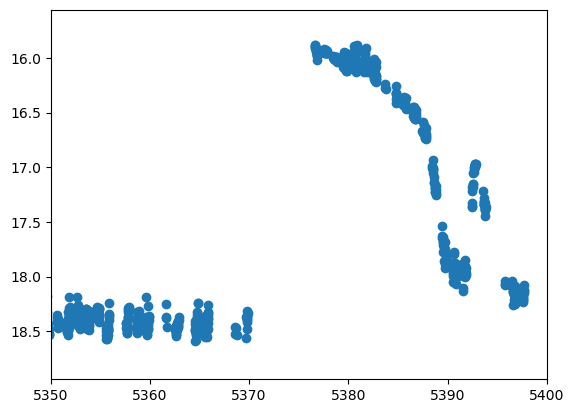

In [35]:
plt.scatter(t, m)
plt.gca().invert_yaxis()
plt.xlim(5350, 5400)

In [42]:
df = pd.DataFrame({"t":t,
                   "m":m,
                   "e":merr})

# Prepare input for Gaussian Process
gp = prep_gp(info[tp], period)

x, y, e = prep_input(df, 
                     'CV', 
                     period, 
                     info[tp], 
                     Roman_max_short_time)

In [38]:
# Bin the data if necessary

if not np.isinf(info[tp]['n_phs']):
    if len(x)/info[tp]['n_phs']>150:
        if info[tp]['fit_binned']==False:
            info[tp]['fit_binned'] = True
        tot_ideal_len = info[tp]['n_phs']*info[tp]['count_per_bins']
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                          y, 
                                                                          e, 
                                                                          info[tp], 
                                                                          n_bins=tot_ideal_len)
    else:
        info[tp]['fit_binned'] = False
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                          y, 
                                                                          e, 
                                                                          info[tp], 
                                                                          n_bins=np.nan)
else:
    if len(x)>1500:
        info[tp]['fit_binned'] = True
        tot_ideal_len = 1500
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                          y, 
                                                                          e, 
                                                                          info[tp], 
                                                                          n_bins=tot_ideal_len)
    else:
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                      y, 
                                                                      e, 
                                                                      info[tp], 
                                                                      n_bins=np.nan)
    

/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [39]:
x_binned = x_binned[~np.isnan(e_binned)]
y_binned = y_binned[~np.isnan(e_binned)]
e_binned = e_binned[~np.isnan(e_binned)]
# ind = y_binned<np.percentile(y_binned, 50)
# x_binned = x_binned[ind]
# y_binned = y_binned[ind]
# e_binned = e_binned[ind]

In [43]:
# Fit Gaussian Process to binned data
gp = fit_gp(x_binned, y_binned, e_binned, info[tp], gp)

In [45]:
# Fitting the gp model
y_median = np.median(y)
max_time_regular = 2000
period = np.nan
(df_roman, 
time_sampling_regular_final,
 gp_y_regular_final,
 gp_std_regular_final,
  gp_y_regular_fit,\
   gp_std_regular_fit) = predict_gp(gp, 
                                    y_binned, 
                                    y_median, 
                                    regular_sampling_fit, 
                                    Roman_sampling_short,
                                    Roman_sampling_long, 
                                    info[tp], 
                                    period,
                                    max_time_regular
                                    )

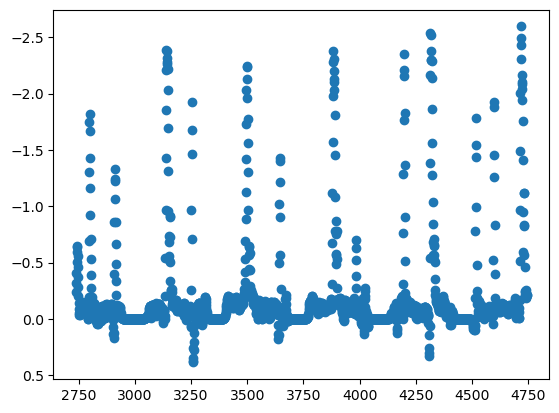

In [46]:
plt.scatter(time_sampling_regular_final,
           gp_y_regular_final)
# plt.scatter(x_binned, y_sim, color='g')

# plt.xlim(100, 175)
plt.gca().invert_yaxis()